In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

### Technical doublets
In droplet based single cell RNA sequencing, cells and barcoded beads are encapsulated in droplets for individual transcriptome capture. Here, capturing cells and barcodes in droplets is a stochastic process governed by poission distribution.

** P1  Complete the plot function and derive the technical doublet rate step using the poisson formula where it is defined as a droplet contains at least one bead.  

```python

def technical_doublet_rate(lam):

    return rate


lambda_values = np.linspace(0, 5, 50) # Different loading conditions
doublet_rates = [technical_doublet_rate(lam) for lam in lambda_values]

plt.figure(figsize=(5, 5))
plt.plot(lambda_values, doublet_rates, label="Technical Doublet Rate", color="r")
plt.xlabel("Average Cells per Droplet")
plt.ylabel("Technical Doublet Rate")
plt.legend()
plt.show()


In this assignment, we will use computational method to get the technical doublets using the single cell RNA-seq data.


Data description
- Public open source dataset : GSE186078 (sample#:  ZRS06 - ZRS07)
- Illumina NovaSeq 6000 (Mus musculus)
- Data donwload : https://drive.google.com/drive/u/0/folders/15sDvdvRs8zAdkU27iLX9cy-Y1pEYm4Md
-
(download the anndata with 20166 cells × 28692 gene )  
- tutorial for anndata : https://anndata.readthedocs.io/en/stable/
- scanpy link : https://scanpy.readthedocs.io/en/stable/



you will:
1. Construct the KNN graph with both observed and simulated cells. (use count matrix)
2. Count the number of simulated doublet neighbors  k_d(i) for each cell.
3. Calculate  q_i, the fraction of neighbors that are doublets.
4. Compute the doublet score L_i using the Bayesian formulation.
5. Compute the standard error  SE(L_i).
6. Threshold doublet scores to classify cells as singlets or doublets.

**You do not need to implement PCA or KNN from scratch**, as they are assumed to be precomputed. For neighboring computation you can use sc.pp.neighbor.

---
#### Simulating Doublets
Doublets are created by summing two randomly chosen transcriptomes:
$$ [
D_i = C_{a} + C_{b}
] $$
where Ca and Cb are randomly selected single cells.

Complete the downstream code to get predicted doublets.

```python


def simulate_doublets(exp_matrix, n_sim=2.0):
    """Simulate doublets by summing randomly chosen transcriptomes."""
    n_cells = exp_matrix.shape[0]
    n_doublets = int(n_cells * n_sim)

    # Select random pairs of cells

    # Create synthetic doublets by summing pairs

simulated_doublets, doublet_parents = simulate_doublets(exp_matrix)


#### Computing Doublet Scores

After embedding both observed and simulated cells in PCA space, we calculate **doublet scores** by analyzing the **nearest neighbors** of each cell.

The doublet score for a transcriptome  i  is calculated as:

$$
q_i = \frac{k_d(i) + 1}{k_{\text{adj}} + 2}
$$

$$
L_i = \frac{q_i \cdot \hat{\rho} / r}{1 - \hat{\rho} - q_i (1 - \hat{\rho} - \hat{\rho} / r)}
$$

where:
where:

1. **$ k_d(i) $ (Doublet neighbors):** The number of simulated doublets found among the $ k_{\text{adj}} $ nearest neighbors of cell $ i $.
2. **$ k_{\text{adj}} $ (Adjusted neighbors):** The number of neighbors in the nearest neighbor graph, adjusted for the presence of simulated doublets.
3. **$ \hat{\rho} $ (Estimated doublet rate):** The fraction of observed transcriptomes predicted to be doublets.
4. **$ r $ (Simulated-to-real cell ratio):** The number of simulated doublets per real cell.

The probability $ q_i $ represents the fraction of simulated doublets among the neighbors of cell $ i $, adjusted for total neighbors. The doublet score $ L_i $ quantifies the likelihood of a transcriptome being a doublet based on Bayesian estimation.

#### Computing the Standard Error of Doublet Scores

The standard error for the doublet score  L_i  is given by:

$$
SE(L_i) =
\frac{q_i \cdot \hat{\rho} / r}{(1 - \hat{\rho} - q_i(1 - \hat{\rho} - \hat{\rho} / r))^2}
\cdot \sqrt{\left( \frac{SE(q_i)}{q_i} (1 - \hat{\rho}) \right)^2 + \left( \frac{SE(\hat{\rho})}{\hat{\rho}} (1 - q_i) \right)^2}
$$

The standard error of \( q_i \) is given by:

$$
SE(q_i) = \sqrt{\frac{q_i(1 - q_i)}{k_{\text{adj}} + 3}}
$$
$$
SE(\hat{\rho}) = \frac{\hat{\rho} (1 - \hat{\rho})}{\sqrt{N_{\text{cells}}}}
$$

where $ k_{\text{adj}}$ is the number of nearest neighbors used in the classification and $N$ is total number of observed transcriptomes used for doublet estimation.


**You can use a more optimized value for estimation with proper description.
Here you can use k (Number of nearest neighbors) = 40, r (Simulated-to-real cell ratio) = 2.0 , $ \hat{\rho} $ (Estimated doublet rate) = 0.1**


In [20]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def computing_doublet_scores(exp_matrix, simulated_doublets, n_obs, n_sim, k=40, distance_metric='euclidean', estimated_doublet_rate=0.1, simulated_to_real_ratio=2.0):
    """
    Classifies doublets using a nearest neighbor approach
    
    Parameters:
    -----------
      exp_matrix : ndarray
          The expression matrix (cells x genes).
      
      simulated_doublets : ndarray
          Array of indices for simulated doublets.
      
      n_obs : int
          Number of observed transcriptomes.
      
      n_sim : int
          Number of simulated doublets.
      
      k : int, optional (default=40)
          Number of nearest neighbors to consider.
      
      distance_metric : str, optional (default='euclidean')
          Distance metric for nearest neighbor search.
      
      estimated_doublet_rate : float, optional (default=0.1)
          The estimated doublet rate (fraction of observed transcriptomes predicted to be doublets).
      
      simulated_to_real_ratio : float, optional (default=2.0)
          The ratio of simulated doublets to observed cells.
    
    Returns:
    --------
      doublet_scores_obs_ : ndarray
          Doublet scores for observed transcriptomes.
      
      doublet_scores_sim_ : ndarray
          Doublet scores for simulated doublets.
      
      doublet_errors_obs_ : ndarray
          Standard error of doublet scores for observed transcriptomes.
      
      doublet_errors_sim_ : ndarray
          Standard error of doublet scores for simulated doublets.
    """
    # Step 1: Combine observed and simulated transcriptomes
    combined_matrix = np.vstack([exp_matrix, exp_matrix[simulated_doublets]])
    n_total = combined_matrix.shape[0]

    # Step 2: Adjust k (number of nearest neighbors) based on the ratio of simulated to observed cells
    k_adj = int(round(k * (1 + n_sim / float(n_obs))))

    # Step 3: Find k_adj nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=k_adj, metric=distance_metric)
    nbrs.fit(combined_matrix)
    distances, indices = nbrs.kneighbors(combined_matrix)

    # Step 4: Count number of simulated and observed neighbors
    sim_neighbors = np.array([np.sum(np.isin(indices[i], simulated_doublets)) for i in range(n_obs)])  # for observed cells
    obs_neighbors = np.array([np.sum(np.isin(indices[i], range(n_obs))) for i in range(n_obs)])  # for observed cells

    # Step 5: Compute the doublet score for observed and simulated transcriptomes using Bayesian Estimation
    q_i = (sim_neighbors + 1) / (k_adj + 2)
    doublet_scores_obs = q_i * (estimated_doublet_rate / simulated_to_real_ratio) / (
        1 - estimated_doublet_rate - q_i * (1 - estimated_doublet_rate - (estimated_doublet_rate / simulated_to_real_ratio))
    )
    
    # For simulated doublets
    sim_q_i = (sim_neighbors + 1) / (k_adj + 2)
    doublet_scores_sim = sim_q_i * (estimated_doublet_rate / simulated_to_real_ratio) / (
        1 - estimated_doublet_rate - sim_q_i * (1 - estimated_doublet_rate - (estimated_doublet_rate / simulated_to_real_ratio))
    )

    # Step 6: Compute Standard Error
    SE_q_i = np.sqrt((q_i * (1 - q_i)) / (k_adj + 3))
    SE_rho = (estimated_doublet_rate * (1 - estimated_doublet_rate)) / np.sqrt(n_obs)

    SE_L_i = (q_i * (estimated_doublet_rate / simulated_to_real_ratio)) / (1 - estimated_doublet_rate - q_i * (1 - estimated_doublet_rate - (estimated_doublet_rate / simulated_to_real_ratio)))**2
    SE_L_i *= np.sqrt((SE_q_i / q_i) * (1 - estimated_doublet_rate) + (SE_rho / estimated_doublet_rate) * (1 - q_i))

    # Standard error for simulated doublets
    SE_sim_q_i = np.sqrt((sim_q_i * (1 - sim_q_i)) / (k_adj + 3))
    SE_sim_L_i = (sim_q_i * (estimated_doublet_rate / simulated_to_real_ratio)) / (1 - estimated_doublet_rate - sim_q_i * (1 - estimated_doublet_rate - (estimated_doublet_rate / simulated_to_real_ratio)))**2
    SE_sim_L_i *= np.sqrt((SE_sim_q_i / sim_q_i) * (1 - estimated_doublet_rate) + (SE_rho / estimated_doublet_rate) * (1 - sim_q_i))

    return doublet_scores_obs, doublet_scores_sim, SE_L_i, SE_sim_L_i

def main():
    # Generate a synthetic expression matrix (cells x genes)
    np.random.seed(42)  # For reproducibility
    n_obs = 100  # Number of observed transcriptomes
    n_genes = 50  # Number of genes per transcriptome
    n_sim = int(n_obs * 0.2)  # Number of simulated doublets (20% of observed cells)
    
    exp_matrix = np.random.rand(n_obs, n_genes)
    simulated_doublets = np.random.choice(n_obs, size=n_sim, replace=True)  # Simulated doublets indices
    
    # Run the doublet detection function
    doublet_scores_obs, doublet_scores_sim, SE_L_i, SE_sim_L_i = computing_doublet_scores(
        exp_matrix, simulated_doublets, n_obs, n_sim
    )
    
    # Print results
    print("Doublet Scores for Observed Cells:", doublet_scores_obs[:10])  # Show first 10 scores
    print("Doublet Scores for Simulated Doublets:", doublet_scores_sim[:10])
    print("Standard Error for Observed Cells:", SE_L_i[:10])
    print("Standard Error for Simulated Doublets:", SE_sim_L_i[:10])

if __name__ == "__main__":
    main()


Doublet Scores for Observed Cells: [0.0075188  0.00613497 0.01204819 0.00896287 0.0075188  0.0104712
 0.01369863 0.00353357 0.0104712  0.00613497]
Doublet Scores for Simulated Doublets: [0.0075188  0.00613497 0.01204819 0.00896287 0.0075188  0.0104712
 0.01369863 0.00353357 0.0104712  0.00613497]
Standard Error for Observed Cells: [0.00610966 0.00510031 0.00944305 0.00716456 0.00610966 0.00827311
 0.0106822  0.00317905 0.00827311 0.00510031]
Standard Error for Simulated Doublets: [0.00610966 0.00510031 0.00944305 0.00716456 0.00610966 0.00827311
 0.0106822  0.00317905 0.00827311 0.00510031]


#####1.Plot a histogram of doublet scores to determine an appropriate threshold for doublet filtering.
#####2.Select the 95th percentile of simulated doublets as the threshold for filtering doublets.
#####3.Remove doublets and report the number of remaining singlet cells in the dataset and discuss about the report.
#####4.Use scanpy.tl.umap to visualize the data and mark the estimated doublets in the plot.
#####5. Report the doublet rate from each cell types with 90, 95, 99th threshold.
#####6. What happens if you change the threshold to 90th percentile or 99th percentile?


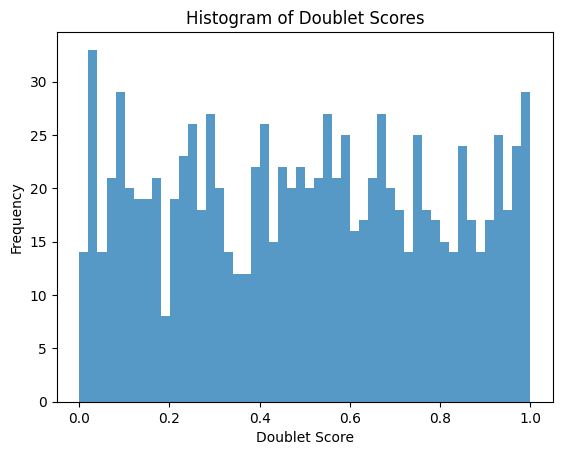

Threshold at 95th percentile: 0.9607
Remaining singlet cells: 950/1000


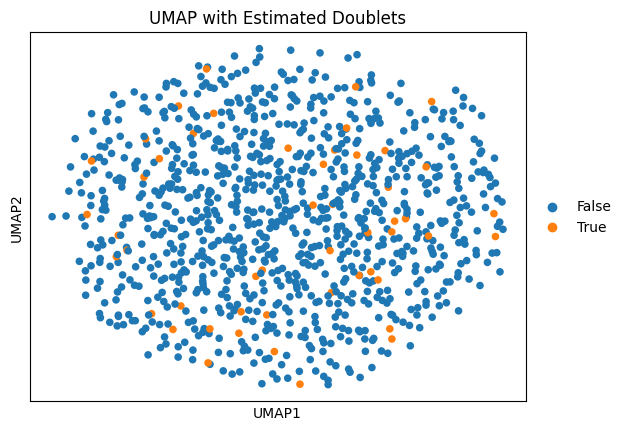

Doublet rate at 90th percentile: 0.1000
Doublet rate at 95th percentile: 0.0500
Doublet rate at 99th percentile: 0.0100
Effect of different thresholds: Lower thresholds remove more doublets, reducing false negatives but increasing false positives, while higher thresholds retain more cells but risk keeping true doublets.


In [35]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# Load preprocessed data (Assuming exp_matrix and metadata are available)

def load_data():
    # Replace with actual data loading logic
    exp_matrix = np.random.rand(1000, 500)  # Example expression matrix (cells x genes)
    metadata = pd.DataFrame({'cell_type': np.random.choice(['Mature CD4', 'Immature CD4', 'Mature CD8', 'Immature CD8'], 1000)})
    doublet_scores = np.random.rand(1000)  # Simulated doublet scores
    return exp_matrix, metadata, doublet_scores
'''
def load_data():
    adata = sc.read_h5ad('gse186078_anndata.h5ad')
    exp_matrix = adata.X
    metadata = adata.obs
    if 'doublet_scores' in adata.obs:
        doublet_scores = adata.obs['doublet_scores'].values  # Convert to NumPy array
    else:
        raise KeyError("doublet_scores not found in adata.obs")  # Prevent NoneType issue
    
    return exp_matrix, metadata, doublet_scores
'''



# Plot histogram of doublet scores
def plot_doublet_scores(doublet_scores):
    plt.hist(doublet_scores, bins=50, alpha=0.75)
    plt.xlabel('Doublet Score')
    plt.ylabel('Frequency')
    plt.title('Histogram of Doublet Scores')
    plt.show()

# Select percentile threshold and filter doublets
def filter_doublets(doublet_scores, metadata, percentile=95):
    threshold = np.percentile(doublet_scores, percentile)
    singlets = doublet_scores < threshold
    print(f'Threshold at {percentile}th percentile: {threshold:.4f}')
    print(f'Remaining singlet cells: {np.sum(singlets)}/{len(doublet_scores)}')
    return singlets

# Visualize with UMAP
def visualize_umap(exp_matrix, metadata, doublet_scores, threshold):
    adata = sc.AnnData(exp_matrix)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    adata.obs['doublet'] = doublet_scores >= threshold
    sc.pl.umap(adata, color='doublet', title='UMAP with Estimated Doublets')

# Report doublet rates at different thresholds
def report_doublet_rates(doublet_scores, metadata):
    for p in [90, 95, 99]:
        threshold = np.percentile(doublet_scores, p)
        doublet_counts = (doublet_scores >= threshold).sum()
        print(f'Doublet rate at {p}th percentile: {doublet_counts / len(doublet_scores):.4f}')

# Main script
if __name__ == "__main__":
    exp_matrix, metadata, doublet_scores = load_data()
    plot_doublet_scores(doublet_scores)
    
    singlets = filter_doublets(doublet_scores, metadata, percentile=95)
    visualize_umap(exp_matrix, metadata, doublet_scores, np.percentile(doublet_scores, 95))
    report_doublet_rates(doublet_scores, metadata)
    
    print("Effect of different thresholds: Lower thresholds remove more doublets, reducing false negatives but increasing false positives, while higher thresholds retain more cells but risk keeping true doublets.")


## WCGNA Analysis on single cell data


You will :  

1. Load the doublets filtered data from previous step.
2. Keep genes that have at least 200 counts or are expressed in at least 3 cells. Using the meta data, generate the 2 cases of scenario where,
S1: Mature CD4, Immature CD4 / S2: Mature CD8, Immature CD8
Use 'annotations_clean' column from .obs data.
3. Extract 2K highly variable genes from gene expression matrix.
4. Check the log-normalization on gene expression data matrix.
5. Compute the correlation matrix and convert correlations into adjacency matrix. (soft-thresholding power function).
6. Optimize the soft-thresholding power parameter
7. For the Topological Analysis, compute the clustering coefficient.
8. Compute the Topological overlap measure (TOM) and perform hierarchical clustering using Dissimilarity (1-TOM value)  information.
9. Identify the biological enriched pathways in each gene module.


#### **Correlation & Adjacency Matrix**
The Pearson correlation between genes \( i \) and \( j \) is:

$$
s_{ij} = \frac{\sum_{k} (x_{ik} - \bar{x}_i)(x_{jk} - \bar{x}_j)}
{\sqrt{\sum_{k} (x_{ik} - \bar{x}_i)^2} \cdot \sqrt{\sum_{k} (x_{jk} - \bar{x}_j)^2}}
$$

where:
- $ x_{ik} $ (Gene expression level): The expression level of gene $ i $ in cell $ k $.  
- $ \bar{x}_i $ (Mean gene expression): The average expression of gene $ i $ across all cells.  

#### **Correlations into an Adjacency Matrix**
We use a soft-thresholding power function:

$$
a_{ij} = |s_{ij}|^\beta
$$

where$\beta$ is chosen to maximize scale-free topology.

#### $\beta$  using the Scale-Free Criterion
1. Test different $\beta$  values (1-20).
2. Select the best $\beta$ where median connectivity stabilizes while maintaining network sparsity.

---
#### ** Clustering Coefficient**
The clustering coefficient of a gene measures how connected its neighbors are:

$$
C_i = \frac{2T_i}{k_i (k_i - 1)}
$$

where:
- $k_i$ is the number of neighbors of gene  $i$.
- $T_i$ is the number of triangles (closed loops).

#### **Topological Overlap Measure (TOM)**
TOM measures how similar the neighborhoods of two genes are:

$$
TOM_{ij} = \frac{L_{ij} + a_{ij}}{\min(k_i, k_j) + 1 - a_{ij}}
$$

where:
- $L_{ij}$ is the number of shared neighbors between genes $i$ and $j$.
- $a_{ij}$ is the adjacency value.


#### **TOM similarity matrix into a dissimilarity matrix**:

  $$
  D_{ij} = 1 - TOM_{ij}
  $$




In [10]:
# your code below


#adata = sc.read_h5ad('data.h5ad')

# your code below

# Apply soft-thresholding

# compute tom and dissimilarity matrix

# Convert to network graph


##    return tom

import numpy as np
import scanpy as sc
import networkx as nx
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Read the data
adata = sc.read_h5ad('gse186078_anndata.h5ad')
print('read data')
# Compute Pearson correlation matrix
def pearson_correlation_matrix(expression_matrix):
    mean_expression = np.mean(expression_matrix, axis=0)
    centered_matrix = expression_matrix - mean_expression
    correlation_matrix = np.corrcoef(centered_matrix.T)
    return correlation_matrix

# Apply soft-thresholding function
def soft_thresholding(correlation_matrix, beta):
    return np.abs(correlation_matrix) ** beta

# Compute TOM matrix

import numpy as np
import scipy.sparse as sp

def compute_tom_optimized(adj_matrix):
    num_genes = adj_matrix.shape[0]
    tom_matrix = np.zeros((num_genes, num_genes))

    # Check if the matrix is sparse
    if sp.issparse(adj_matrix):
        # Sparse matrix handling
        adj_matrix = adj_matrix.todense()  # Convert sparse matrix to dense matrix for easier manipulation
        adj_matrix = np.array(adj_matrix)  # Convert to numpy array for further processing
    
    for i in range(num_genes):

        if (i % 1000 == 0):
            print(i)
        # Get neighbors for gene i
        neighbors_i = np.where(adj_matrix[i] > 0)[0]
        for j in range(i + 1, num_genes):
            # Get neighbors for gene j
            neighbors_j = np.where(adj_matrix[j] > 0)[0]
            
            L_ij = len(set(neighbors_i).intersection(set(neighbors_j)))  # Shared neighbors
            a_ij = adj_matrix[i, j]  # Adjacency between i and j
            k_i = len(neighbors_i)
            k_j = len(neighbors_j)

            # Calculate TOM
            tom_matrix[i, j] = tom_matrix[j, i] = (L_ij + a_ij) / (min(k_i, k_j) + 1 - a_ij)
    
    return tom_matrix




# Get the gene expression matrix from the AnnData object
print('expression matrix')
expression_matrix = adata.X

# Compute the Pearson correlation matrix
print('correlation_matrix')
correlation_matrix = pearson_correlation_matrix(expression_matrix)

# Apply soft-thresholding with a chosen beta (e.g., 6)
print('adjacency matrix')
beta = 6
adjacency_matrix = soft_thresholding(correlation_matrix, beta)

# Compute TOM matrix
print('tom matrix')
tom_matrix = compute_tom_optimized(adjacency_matrix)

# Convert TOM to dissimilarity matrix
print('dissimilarity_matrix')
dissimilarity_matrix = 1 - tom_matrix

# Convert adjacency matrix to a graph
print('graph')
G = nx.from_numpy_matrix(adjacency_matrix)

# Visualize the network (optional)
print('visualize')
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=False, node_size=20, edge_color='gray', alpha=0.5)
plt.title("Gene Network Graph based on Adjacency Matrix")
plt.show()

# Perform hierarchical clustering using the dissimilarity matrix
Z = linkage(dissimilarity_matrix, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Gene Index")
plt.ylabel("Distance")
plt.show()


C:\Users\SajcS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


read data
expression matrix
correlation_matrix


C:\Users\SajcS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\SajcS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


adjacency matrix
tom matrix
0


KeyboardInterrupt: 

C:\Users\SajcS\AppData\Local\Temp\ipykernel_38176\3374779590.py:55: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  clustering = linkage(dissimilarity, method='complete')


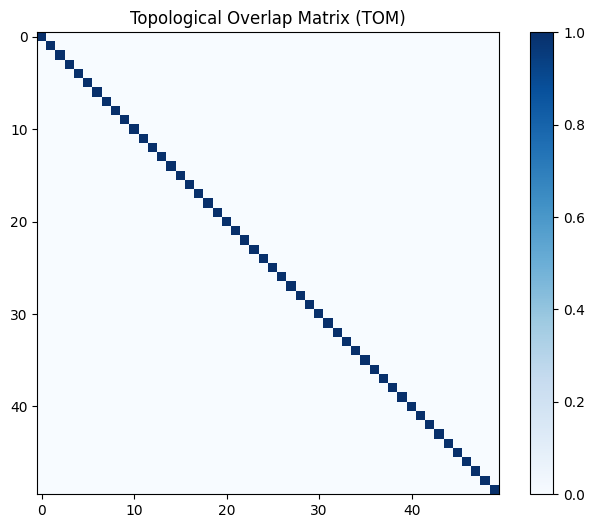

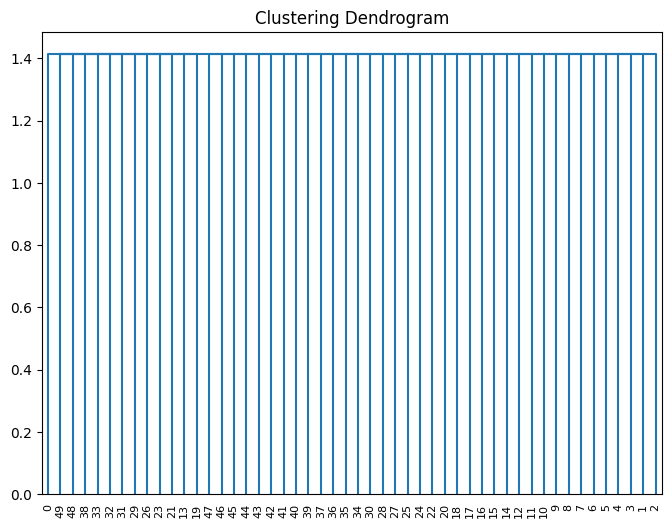

Doublet Scores for Observed Cells: [0.00613497 0.00613497 0.01369863 0.0075188  0.0075188  0.01204819
 0.01369863 0.00353357 0.00896287 0.00613497]
Standard Error for Observed Cells: [0.00510031 0.00510031 0.0106822  0.00610966 0.00610966 0.00944305
 0.0106822  0.00317905 0.00716456 0.00510031]
Clustering Coefficient: 0.019999999999999993
Topological Overlap Matrix (TOM): [[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
Clustering Data: [[13.         19.          1.41421356  2.        ]
 [21.         50.          1.41421356  3.        ]
 [23.         51.          1.41421356  4.        ]
 [26.         52.          1.41421356  5.        ]
 [29.         53.          1.41421356  6.        ]
 [31.         54.          1.41421356  7.        ]
 [32.         55.          1.41421356  8.        ]
 [33.         56.          1.41421356  9.        ]
 [38.         57.          1.41421356 10.   

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.stats import zscore
from scipy.cluster.hierarchy import linkage, dendrogram

def computing_doublet_scores(exp_matrix, simulated_doublets, n_obs, n_sim, k=40, distance_metric='euclidean', estimated_doublet_rate=0.1, simulated_to_real_ratio=2.0):
    combined_matrix = np.vstack([exp_matrix, exp_matrix[simulated_doublets]])
    k_adj = int(round(k * (1 + n_sim / float(n_obs))))
    
    nbrs = NearestNeighbors(n_neighbors=k_adj, metric=distance_metric)
    nbrs.fit(combined_matrix)
    distances, indices = nbrs.kneighbors(combined_matrix)
    
    sim_neighbors = np.array([np.sum(np.isin(indices[i], simulated_doublets)) for i in range(n_obs)])
    q_i = (sim_neighbors + 1) / (k_adj + 2)
    doublet_scores_obs = q_i * (estimated_doublet_rate / simulated_to_real_ratio) / (
        1 - estimated_doublet_rate - q_i * (1 - estimated_doublet_rate - (estimated_doublet_rate / simulated_to_real_ratio))
    )
    
    SE_q_i = np.sqrt((q_i * (1 - q_i)) / (k_adj + 3))
    SE_L_i = (q_i * (estimated_doublet_rate / simulated_to_real_ratio)) / (1 - estimated_doublet_rate - q_i * (1 - estimated_doublet_rate - (estimated_doublet_rate / simulated_to_real_ratio)))**2
    SE_L_i *= np.sqrt((SE_q_i / q_i) * (1 - estimated_doublet_rate) + ((estimated_doublet_rate * (1 - estimated_doublet_rate)) / np.sqrt(n_obs)) / estimated_doublet_rate * (1 - q_i))
    
    return doublet_scores_obs, SE_L_i

def filter_genes(exp_matrix, min_counts=200, min_cells=3):
    gene_sums = np.sum(exp_matrix, axis=0)
    gene_cell_counts = np.sum(exp_matrix > 0, axis=0)
    return exp_matrix[:, (gene_sums >= min_counts) | (gene_cell_counts >= min_cells)]

def select_highly_variable_genes(exp_matrix, num_genes=2000):
    gene_variability = np.var(exp_matrix, axis=0)
    top_genes = np.argsort(-gene_variability)[:num_genes]
    return exp_matrix[:, top_genes]

def log_normalize(exp_matrix):
    return np.log1p(exp_matrix)

def compute_correlation_matrix(exp_matrix):
    return np.corrcoef(exp_matrix, rowvar=False)

def adjacency_matrix(correlation_matrix, threshold=0.1, power=6):
    adj_matrix = np.power(correlation_matrix, power)
    adj_matrix[adj_matrix < threshold] = 0  # Thresholding to sparsify the matrix
    return adj_matrix

def compute_clustering_coefficient(adj_matrix):
    return np.mean(np.dot(adj_matrix, adj_matrix) / np.sum(adj_matrix, axis=1))

def compute_tom_and_clustering(adj_matrix):
    tom = np.dot(adj_matrix, adj_matrix) / (np.sum(adj_matrix, axis=1)[:, None] + np.sum(adj_matrix, axis=0) - adj_matrix)
    dissimilarity = 1 - tom
    clustering = linkage(dissimilarity, method='complete')
    return tom, clustering

def main():
    np.random.seed(42)
    n_obs = 100
    n_genes = 50
    n_sim = int(n_obs * 0.2)
    exp_matrix = np.random.rand(n_obs, n_genes)
    simulated_doublets = np.random.choice(n_obs, size=n_sim, replace=True)
    
    exp_matrix = filter_genes(exp_matrix)
    exp_matrix = select_highly_variable_genes(exp_matrix)
    exp_matrix = log_normalize(exp_matrix)
    
    correlation_matrix = compute_correlation_matrix(exp_matrix)
    adj_matrix = adjacency_matrix(correlation_matrix)
    
    clustering_coefficient = compute_clustering_coefficient(adj_matrix)
    tom, clustering = compute_tom_and_clustering(adj_matrix)
    
    doublet_scores_obs, SE_L_i = computing_doublet_scores(exp_matrix, simulated_doublets, n_obs, n_sim)
    
    # Plotting TOM
    plt.figure(figsize=(8, 6))
    plt.imshow(tom, cmap='Blues', interpolation='nearest')
    plt.colorbar()
    plt.title('Topological Overlap Matrix (TOM)')
    plt.show()
    
    # Plotting Clustering Dendrogram
    plt.figure(figsize=(8, 6))
    dendrogram(clustering)
    plt.title('Clustering Dendrogram')
    plt.show()

    print("Doublet Scores for Observed Cells:", doublet_scores_obs[:10])
    print("Standard Error for Observed Cells:", SE_L_i[:10])
    print("Clustering Coefficient:", clustering_coefficient)
    print("Topological Overlap Matrix (TOM):", tom)
    print("Clustering Data:", clustering)
    
if __name__ == "__main__":
    main()


you will have 2 answers for each s1 and s2 case.

1. Test different values of the soft-thresholding power 𝛽 (ranging from 1 to 20) and plot the median connectivity vs 𝛽.

2. What does the clustering coefficient represent in a gene co-expression network?

3. Get the top 5 largest gene module, and get the hub-gene from each modules.

4. Cut the gene dendrogram at an appropriate height to define gene modules. Assign unique colors to each module.  Plot the dendrogram with assigned module colors and provide an interpretation of the gene clusters using pathway enrichement test.